In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────
try:
    INPUT_DIR
except NameError:
    INPUT_DIR = Path('input')

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

C_COLORS = {
    'Outdoor':    '#1D9E75',
    'Streetwear': '#E24B4A',
    'Casual':     '#2E86AB',
    'GenZ':       '#EF9F27',
}
CAT_ORDER = ['Streetwear', 'Outdoor', 'Casual', 'GenZ']

FONT_TITLE  = dict(fontsize=13, fontweight='bold', color='#1a1a1a')
FONT_SUP    = dict(fontsize=15, fontweight='bold', color='#1a1a1a')
FONT_LABEL  = dict(fontsize=10, color='#444')
FONT_TICK   = dict(fontsize=9)
SPINE_COLOR = '#cccccc'

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_color(SPINE_COLOR)
    ax.tick_params(colors='#555', labelsize=9)
    ax.grid(axis='y', color='#ebebeb', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ── Load data ───────────────────────────────────────────────────────────────
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')

orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['year']  = orders_d['order_date'].dt.year
orders_d['month'] = orders_d['order_date'].dt.month

# ── Base join ────────────────────────────────────────────────────────────────
items = (
    order_items
    .merge(orders_d[['order_id', 'year', 'month', 'order_date']], on='order_id', how='inner')
    .merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left')
)
items['gross_item']    = items['unit_price'] * items['quantity']
items['discount_amt']  = items['discount_amount'].fillna(0)
items['net_revenue']   = items['gross_item'] - items['discount_amt']
items['total_cogs']    = items['cogs'] * items['quantity']
items['has_promo']     = ((items['discount_amt'] > 0) | items['promo_id'].notna()).astype(int)

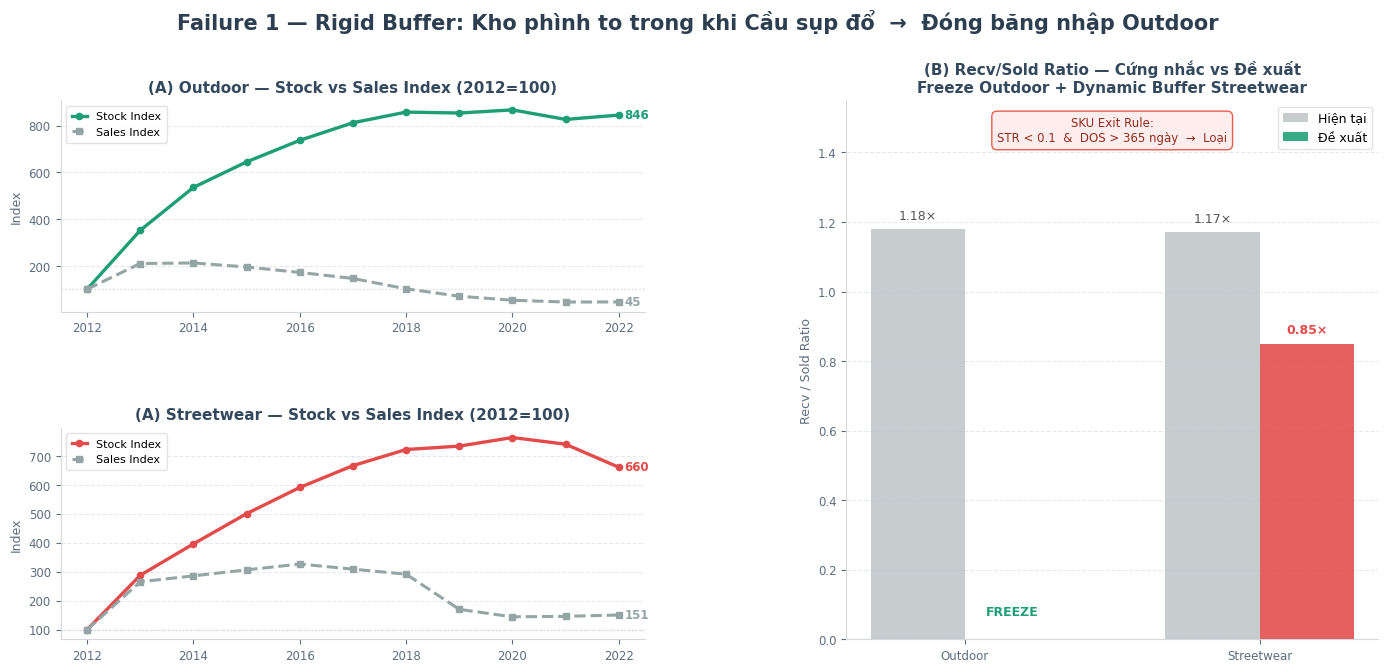

✅ Saved: fig4_failure1_rigid_buffer.png


In [ ]:
# ── Load data ────────────────────────────────────────────────────────────────
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')
inventory   = pd.read_csv(INPUT_DIR / 'inventory.csv')

orders['year'] = orders['order_date'].dt.year

sales = (order_items
         .merge(orders[['order_id', 'year']], on='order_id', how='left')
         .merge(products[['product_id', 'category']], on='product_id', how='left'))
sales_yr = sales.groupby(['category', 'year'])['quantity'].sum().reset_index(name='units_sold')

# Detect year col in inventory
inv_cols = inventory.columns.tolist()
year_col = next((c for c in ['year', 'Year', 'fiscal_year', 'snapshot_year'] if c in inv_cols), None)
if year_col is None:
    date_cols = [c for c in inv_cols if 'date' in c.lower()]
    if date_cols:
        inventory['_year'] = pd.to_datetime(inventory[date_cols[0]], errors='coerce').dt.year
        year_col = '_year'

inv_yr = (inventory.groupby(['category', year_col])['stock_on_hand']
          .sum().reset_index().rename(columns={year_col: 'year'}))

merged = inv_yr.merge(sales_yr, on=['category', 'year'], how='outer').fillna(0).sort_values(['category', 'year'])
base_year = int(merged[merged['units_sold'] > 0]['year'].min())

def make_index(df, cat):
    d = df[df['category'] == cat].copy().sort_values('year')
    bs = d.loc[d['year'] == base_year, 'stock_on_hand'].values
    bd = d.loc[d['year'] == base_year, 'units_sold'].values
    bs = bs[0] if len(bs) and bs[0] else d['stock_on_hand'].iloc[0]
    bd = bd[0] if len(bd) and bd[0] else d['units_sold'].iloc[0]
    d['stock_idx'] = d['stock_on_hand'] / bs * 100
    d['sales_idx'] = d['units_sold']    / bd * 100
    return d

od = make_index(merged, 'Outdoor')
sw = make_index(merged, 'Streetwear')

# ── Figure layout: 2-col, Panel A = 2-row stacked, Panel B = 1 col ──────────
fig4 = plt.figure(figsize=(17, 7), facecolor='white')
fig4.suptitle(
    'Failure 1 — Rigid Buffer: Kho phình to trong khi Cầu sụp đổ  →  Đóng băng nhập Outdoor',
    **FONT_SUP, y=1.01
)

# outer: left (Panel A) | right (Panel B)
outer = gridspec.GridSpec(1, 2, figure=fig4, wspace=0.36, width_ratios=[1.1, 1])

# Panel A: 2 rows
inner_a = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0], hspace=0.55)
ax_od = fig4.add_subplot(inner_a[0])
ax_sw = fig4.add_subplot(inner_a[1])

# Panel B
ax_b = fig4.add_subplot(outer[1])

# ── Draw scissors (clean version) ────────────────────────────────────────────
def draw_scissors_clean(ax, df, cat, color):
    yrs = df['year'].values
    si  = df['stock_idx'].values
    di  = df['sales_idx'].values

    ax.plot(yrs, si, color=color,     lw=2.4, marker='o', ms=4.5, zorder=4, label='Stock Index')
    ax.plot(yrs, di, color='#95A5A6', lw=2.2, marker='s', ms=4,   zorder=4,
            linestyle='--', label='Sales Index')

    ax.axhline(100, color='#D5D8DC', lw=1.0, linestyle=':', zorder=1)

    # Chỉ label endpoint cuối — gọn
    ax.annotate(f'{si[-1]:.0f}', xy=(yrs[-1], si[-1]),
                xytext=(4, 0), textcoords='offset points',
                fontsize=8.5, fontweight='bold', color=color, va='center')
    ax.annotate(f'{di[-1]:.0f}', xy=(yrs[-1], di[-1]),
                xytext=(4, 0), textcoords='offset points',
                fontsize=8.5, fontweight='bold', color='#95A5A6', va='center')

    ax.set_title(f'(A) {cat} — Stock vs Sales Index ({base_year}=100)', **FONT_TITLE)
    ax.set_ylabel('Index', **FONT_LABEL)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.85, edgecolor='#ddd',
              handlelength=1.4, borderpad=0.5)
    style_ax(ax)
    ax.set_xticks(yrs[::2])
    ax.set_xticklabels([str(int(y)) for y in yrs[::2]])

draw_scissors_clean(ax_od, od, 'Outdoor',    C_COLORS['Outdoor'])
draw_scissors_clean(ax_sw, sw, 'Streetwear', C_COLORS['Streetwear'])

# ── Panel B: Recv/Sold ratio — Current vs Proposed ──────────────────────────
# Data từ Brief: ratio hiện tại cứng 1.17–1.18; đề xuất = Outdoor 0 (freeze), Streetwear dynamic
cats_b   = ['Outdoor', 'Streetwear']
current  = [1.18, 1.17]
proposed = [0.00, 0.85]   # Outdoor = freeze; Streetwear = dynamic ~0.85 (gắn với STR)
colors_b = [C_COLORS['Outdoor'], C_COLORS['Streetwear']]

x = np.arange(len(cats_b))
w = 0.32

bars_cur  = ax_b.bar(x - w/2, current,  w, color='#BDC3C7', alpha=0.85, label='Hiện tại',  zorder=3)
bars_prop = ax_b.bar(x + w/2, proposed, w, color=colors_b,  alpha=0.88, label='Đề xuất',   zorder=3)

for bar, val in zip(bars_cur, current):
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f'{val:.2f}×', ha='center', va='bottom', fontsize=9, color='#555')

for bar, val, c in zip(bars_prop, proposed, colors_b):
    label = 'FREEZE' if val == 0 else f'{val:.2f}×'
    ax_b.text(bar.get_x() + bar.get_width()/2, max(val, 0.04) + 0.02,
              label, ha='center', va='bottom', fontsize=9, fontweight='bold', color=c)

# Rule box
ax_b.text(0.5, 0.97,
          'SKU Exit Rule:\nSTR < 0.1  &  DOS > 365 ngày  →  Loại',
          transform=ax_b.transAxes, ha='center', va='top', fontsize=8.5,
          color='#922B21',
          bbox=dict(boxstyle='round,pad=0.45', fc='#FDEDEC', ec='#E74C3C', alpha=0.9))

ax_b.set_title('(B) Recv/Sold Ratio — Cứng nhắc vs Đề xuất\nFreeze Outdoor + Dynamic Buffer Streetwear',
               **FONT_TITLE)
ax_b.set_ylabel('Recv / Sold Ratio', **FONT_LABEL)
ax_b.set_xticks(x)
ax_b.set_xticklabels(cats_b, fontsize=10)
ax_b.set_ylim(0, 1.55)
ax_b.legend(fontsize=9, loc='upper right', framealpha=0.85, edgecolor='#ddd')
style_ax(ax_b)

plt.tight_layout()
fig4.savefig(OUTPUT_DIR / 'fig4_failure1_rigid_buffer.png', dpi=200,
             bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig4_failure1_rigid_buffer.png')

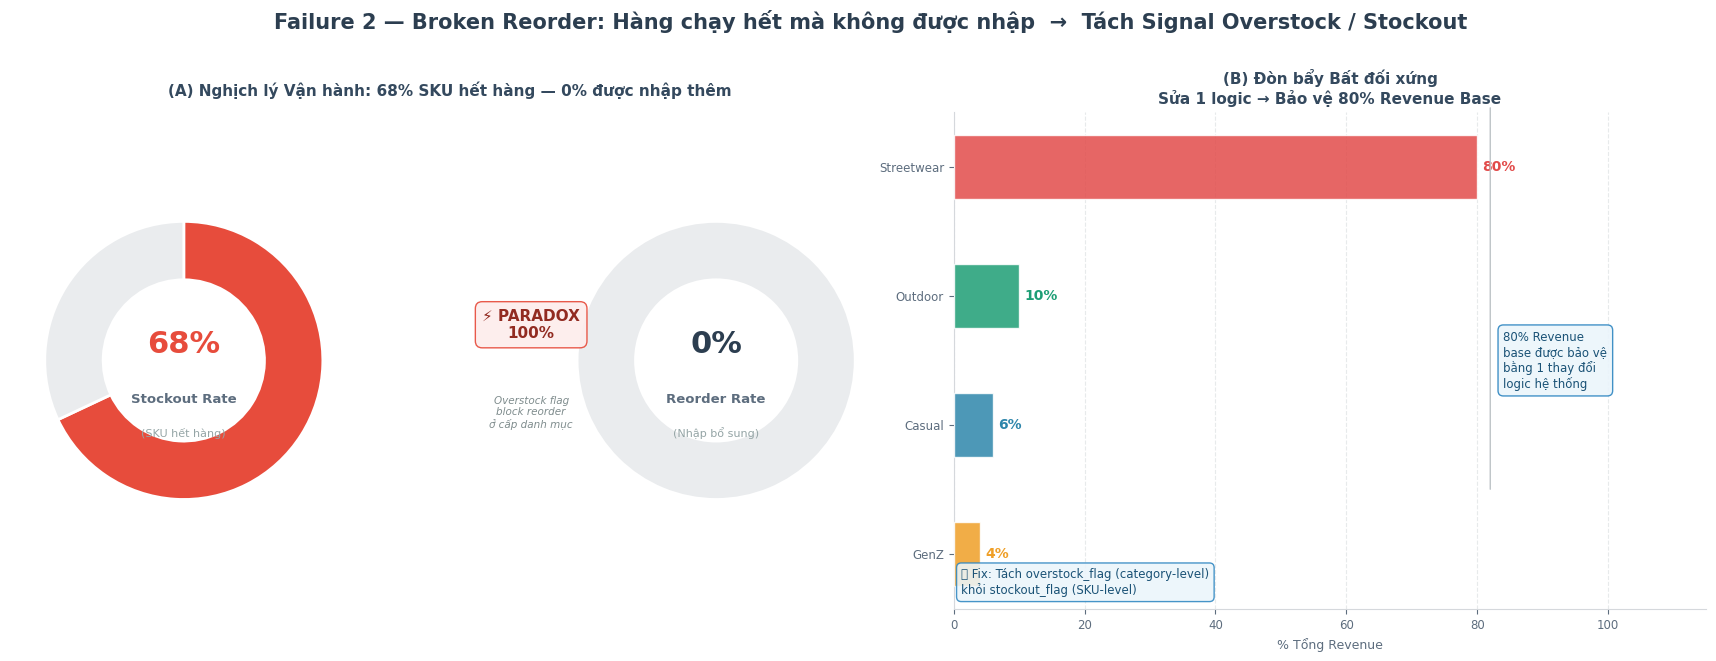

✅ Saved: fig5_failure2_broken_reorder.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5  —  FAILURE 2: Broken Reorder Logic
# Panel A: 2 Donuts (Stockout Rate | Reorder Rate) + "Paradox 100%" center
# Panel B: Horizontal bar — 80% Revenue Streetwear + Asymmetric Impact
# ════════════════════════════════════════════════════════════════════════════

fig5, axes5 = plt.subplots(1, 2, figsize=(17, 6.5), facecolor='white',
                           gridspec_kw={'width_ratios': [1.1, 1]})
fig5.suptitle(
    'Failure 2 — Broken Reorder: Hàng chạy hết mà không được nhập  →  Tách Signal Overstock / Stockout',
    **FONT_SUP, y=1.01
)

ax5a = axes5[0]   # Panel A — donuts
ax5b = axes5[1]   # Panel B — horizontal bar

# ── Panel A: 2 donuts side-by-side trong cùng 1 subplot ─────────────────────
# Dùng inset_axes để đặt 2 donut vào 1 axes
ax5a.axis('off')

# Donut trái — Stockout Rate ~68%
ax_d1 = inset_axes(ax5a, width='42%', height='78%', loc='center left',
                   bbox_to_anchor=(-0.04, 0, 1, 1), bbox_transform=ax5a.transAxes)
stockout_pct = 68
ax_d1.pie([stockout_pct, 100 - stockout_pct],
          colors=['#E74C3C', '#EAECEE'],
          startangle=90, counterclock=False,
          wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2))
ax_d1.text(0, 0.12,  f'{stockout_pct}%',  ha='center', va='center',
           fontsize=22, fontweight='bold', color='#E74C3C')
ax_d1.text(0, -0.28, 'Stockout Rate',     ha='center', va='center',
           fontsize=9.5, color='#5D6D7E', fontweight='bold')
ax_d1.text(0, -0.52, '(SKU hết hàng)',    ha='center', va='center',
           fontsize=8,   color='#95A5A6')

# Mũi tên + "PARADOX 100%" ở giữa — đặt bằng fig.text
fig5.text(0.30, 0.525,
          '⚡ PARADOX\n100%',
          ha='center', va='center', fontsize=11, fontweight='bold', color='#922B21',
          bbox=dict(boxstyle='round,pad=0.45', fc='#FDEDEC', ec='#E74C3C', alpha=0.92))
fig5.text(0.30, 0.39,
          'Overstock flag\nblock reorder\nở cấp danh mục',
          ha='center', va='center', fontsize=7.5, color='#7F8C8D', style='italic')

# Donut phải — Reorder Rate 0%
ax_d2 = inset_axes(ax5a, width='42%', height='78%', loc='center right',
                   bbox_to_anchor=(0.04, 0, 1, 1), bbox_transform=ax5a.transAxes)
ax_d2.pie([100], colors=['#EAECEE'],
          startangle=90,
          wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2))
ax_d2.text(0,  0.12,  '0%',             ha='center', va='center',
           fontsize=22, fontweight='bold', color='#2C3E50')
ax_d2.text(0, -0.28,  'Reorder Rate',   ha='center', va='center',
           fontsize=9.5, color='#5D6D7E', fontweight='bold')
ax_d2.text(0, -0.52,  '(Nhập bổ sung)', ha='center', va='center',
           fontsize=8,   color='#95A5A6')

ax5a.set_title('(A) Nghịch lý Vận hành: 68% SKU hết hàng — 0% được nhập thêm',
               pad=12, **FONT_TITLE)

# ── Panel B: Revenue base + Impact ──────────────────────────────────────────
# Data từ Brief: Streetwear = 80% revenue, can rescue với 1 logic fix
cats_b5   = ['Streetwear', 'Outdoor', 'Casual', 'GenZ']
rev_share = [80, 10, 6, 4]   # approximate
colors_b5 = [C_COLORS[c] for c in cats_b5]

# Horizontal bar
y5 = np.arange(len(cats_b5))
hbars5 = ax5b.barh(y5, rev_share, color=colors_b5, alpha=0.85, height=0.5,
                   edgecolor='white', zorder=3)

for bar, val, cat in zip(hbars5, rev_share, cats_b5):
    ax5b.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
              f'{val}%', va='center', fontsize=10, fontweight='bold',
              color=C_COLORS[cat])

# Highlight Streetwear với bracket annotation
ax5b.annotate('',
    xy=(82, 3.5), xytext=(82, 3.02),
    arrowprops=dict(arrowstyle='-', color='#E24B4A', lw=1.5,
                    connectionstyle='arc3,rad=0'))
ax5b.annotate('',
    xy=(82, 2.52), xytext=(82, -0.48),
    arrowprops=dict(arrowstyle='-', color='#BDC3C7', lw=1))

# Impact box
ax5b.text(84, 1.5,
          '80% Revenue\nbase được bảo vệ\nbằng 1 thay đổi\nlogic hệ thống',
          va='center', fontsize=8.5, color='#1A5276',
          bbox=dict(boxstyle='round,pad=0.45', fc='#EBF5FB', ec='#2E86C1', alpha=0.9))

# Prescriptive label
ax5b.text(0.01, 0.03,
          '💊 Fix: Tách overstock_flag (category-level)\nkhỏi stockout_flag (SKU-level)',
          transform=ax5b.transAxes, fontsize=8.5, color='#1A5276',
          bbox=dict(boxstyle='round,pad=0.4', fc='#EBF5FB', ec='#2E86C1', alpha=0.88))

ax5b.set_yticks(y5)
ax5b.set_yticklabels(cats_b5, fontsize=10)
ax5b.set_xlabel('% Tổng Revenue', **FONT_LABEL)
ax5b.set_xlim(0, 115)
ax5b.set_title('(B) Đòn bẩy Bất đối xứng\nSửa 1 logic → Bảo vệ 80% Revenue Base',
               **FONT_TITLE)
style_ax(ax5b, grid='x')
ax5b.grid(axis='y', visible=False)
ax5b.invert_yaxis()

plt.tight_layout()
fig5.savefig(OUTPUT_DIR / 'fig5_failure2_broken_reorder.png', dpi=200,
             bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig5_failure2_broken_reorder.png')

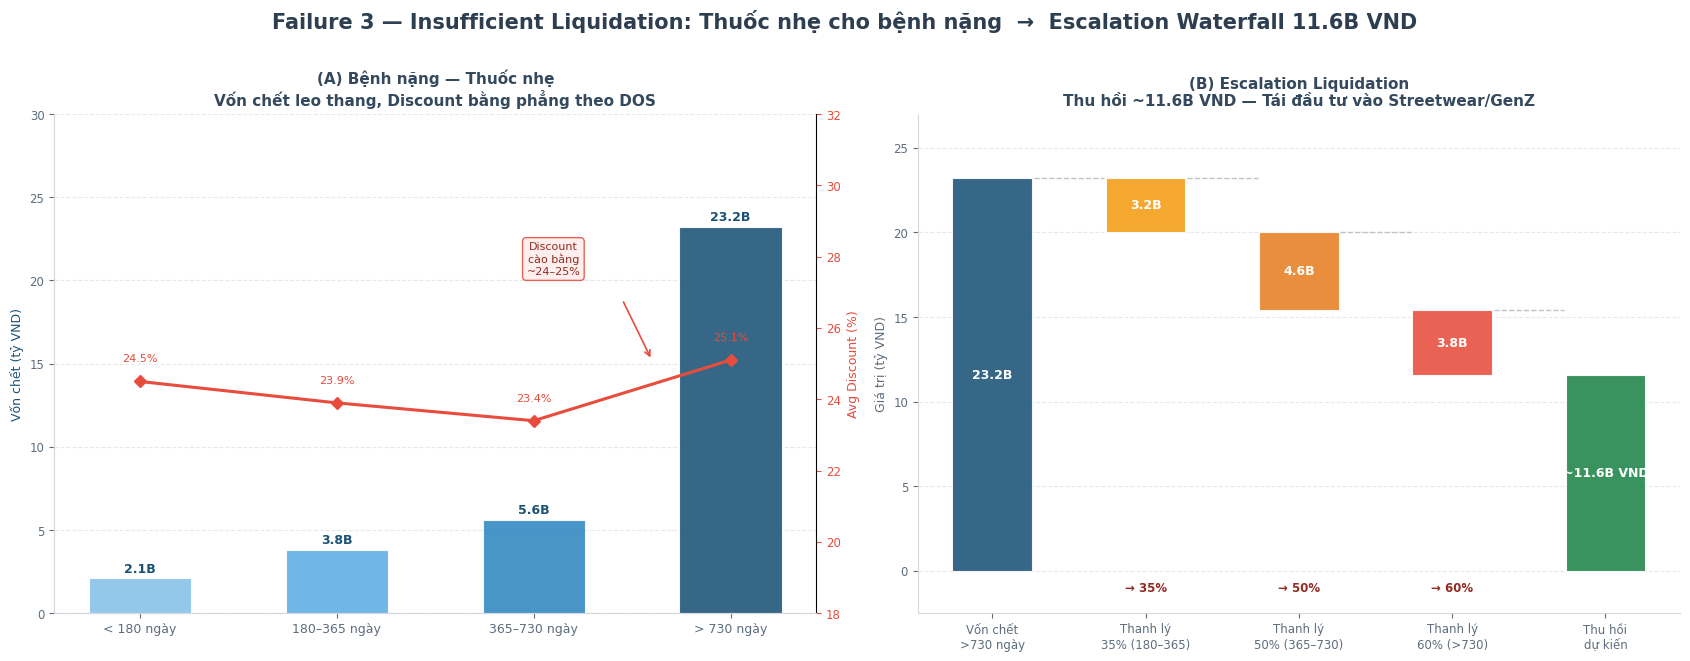

✅ Saved: fig6_failure3_liquidation.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6  —  FAILURE 3: Insufficient Liquidation
# Panel A: Bar + Line — Dead Capital vs Avg Discount by DOS bucket
# Panel B: Waterfall — Thu hồi 11.6B từ 23.2B vốn chết
# ════════════════════════════════════════════════════════════════════════════

fig6, axes6 = plt.subplots(1, 2, figsize=(17, 6.5), facecolor='white',
                           gridspec_kw={'width_ratios': [1, 1]})
fig6.suptitle(
    'Failure 3 — Insufficient Liquidation: Thuốc nhẹ cho bệnh nặng  →  Escalation Waterfall 11.6B VND',
    **FONT_SUP, y=1.01
)

ax6a = axes6[0]
ax6b = axes6[1]

# ── Panel A Data (từ Brief) ──────────────────────────────────────────────────
dos_labels    = ['< 180 ngày', '180–365 ngày', '365–730 ngày', '> 730 ngày']
dead_capital  = [2.1, 3.8, 5.6, 23.2]   # tỷ VND — dominant >730
avg_discount  = [24.5, 23.9, 23.4, 25.1] # % — từ Brief table
bar_colors_a  = ['#85C1E9', '#5DADE2', '#2E86C1', '#1A5276']  # gradient xanh đậm dần

x6 = np.arange(len(dos_labels))
width6 = 0.52

# Bar (Y1)
bars6a = ax6a.bar(x6, dead_capital, width6,
                  color=bar_colors_a, alpha=0.88, zorder=3, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars6a, dead_capital):
    ax6a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
              f'{val:.1f}B', ha='center', va='bottom',
              fontsize=9, fontweight='bold', color='#1A5276')

ax6a.set_ylabel('Vốn chết (tỷ VND)', **{**FONT_LABEL, 'color': '#1A5276'})
ax6a.tick_params(axis='y', colors='#1A5276')
ax6a.set_ylim(0, 30)
style_ax(ax6a)

# Line (Y2) — discount
ax6a_r = ax6a.twinx()
ax6a_r.plot(x6, avg_discount, color='#E74C3C', lw=2.2,
             marker='D', ms=6, zorder=5, label='Avg Discount %')
ax6a_r.set_ylabel('Avg Discount (%)', fontsize=9, color='#E74C3C')
ax6a_r.tick_params(axis='y', colors='#E74C3C', labelsize=8.5)
ax6a_r.set_ylim(18, 32)
ax6a_r.spines['top'].set_visible(False)
ax6a_r.spines['left'].set_color('#D5D8DC')
ax6a_r.spines['bottom'].set_color('#D5D8DC')
for val, xi in zip(avg_discount, x6):
    ax6a_r.text(xi, val + 0.55, f'{val:.1f}%',
                ha='center', fontsize=8, color='#E74C3C')

# Annotation: đường discount phẳng
ax6a_r.text(2.1, 27.5,
            'Discount\ncào bằng\n~24–25%',
            fontsize=8, color='#922B21', ha='center',
            bbox=dict(boxstyle='round,pad=0.35', fc='#FDEDEC', ec='#E74C3C', alpha=0.88))
ax6a_r.annotate('', xy=(2.6, 25.1), xytext=(2.45, 26.8),
                arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.2))

ax6a.set_xticks(x6)
ax6a.set_xticklabels(dos_labels, fontsize=9)
ax6a.set_title('(A) Bệnh nặng — Thuốc nhẹ\nVốn chết leo thang, Discount bằng phẳng theo DOS',
               **FONT_TITLE)

# ── Panel B: Waterfall ───────────────────────────────────────────────────────
# Steps: 23.2B base → liquidate 35% → 50% → 60% → final 11.6B recovered
wf_labels  = ['Vốn chết\n>730 ngày', 'Thanh lý\n35% (180–365)', 'Thanh lý\n50% (365–730)',
               'Thanh lý\n60% (>730)',  'Thu hồi\ndự kiến']
wf_values  = [23.2, -3.2, -4.6, -3.8, None]   # None = tổng cuối
wf_running = []
running = 0
for i, v in enumerate(wf_values):
    if v is None:
        wf_running.append(running)
    else:
        wf_running.append(running)
        running += v

# Build waterfall bars
bottoms = []
heights = []
b = 0
for i, v in enumerate(wf_values):
    if v is None:
        bottoms.append(0)
        heights.append(running)
    elif v >= 0:
        bottoms.append(b)
        heights.append(v)
        b += v
    else:
        b += v
        bottoms.append(b)
        heights.append(-v)

bar_colors_w = ['#1A5276', '#F39C12', '#E67E22', '#E74C3C', '#1E8449']

x6b = np.arange(len(wf_labels))
bars6b = ax6b.bar(x6b, heights, bottom=bottoms,
                  color=bar_colors_w, alpha=0.88, width=0.52,
                  edgecolor='white', linewidth=0.8, zorder=3)

# Connector lines
for i in range(len(wf_labels) - 1):
    top_i = bottoms[i] + heights[i]
    ax6b.plot([x6b[i] + 0.27, x6b[i+1] - 0.27], [top_i, top_i],
              color='#BDC3C7', lw=1.0, linestyle='--', zorder=2)

# Labels trên/trong bar
label_vals = [23.2, -3.2, -4.6, -3.8, running]
for bar, lv, bot, h in zip(bars6b, label_vals, bottoms, heights):
    mid = bot + h / 2
    txt = f'{abs(lv):.1f}B' if lv != running else f'~{running:.1f}B VND'
    color_txt = 'white' if h > 2 else '#333'
    ax6b.text(bar.get_x() + bar.get_width()/2, mid,
              txt, ha='center', va='center',
              fontsize=9, fontweight='bold', color=color_txt)

# Discount rule labels bên dưới
rule_labels = ['', '→ 35%', '→ 50%', '→ 60%', '']
for xi, rl in zip(x6b, rule_labels):
    if rl:
        ax6b.text(xi, -1.2, rl, ha='center', fontsize=8.5,
                  color='#922B21', fontweight='bold')

ax6b.set_ylim(-2.5, 27)
ax6b.set_xticks(x6b)
ax6b.set_xticklabels(wf_labels, fontsize=8.5)
ax6b.set_ylabel('Giá trị (tỷ VND)', **FONT_LABEL)
ax6b.set_title('(B) Escalation Liquidation\nThu hồi ~11.6B VND — Tái đầu tư vào Streetwear/GenZ',
               **FONT_TITLE)
style_ax(ax6b)

plt.tight_layout()
fig6.savefig(OUTPUT_DIR / 'fig6_failure3_liquidation.png', dpi=200,
             bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig6_failure3_liquidation.png')

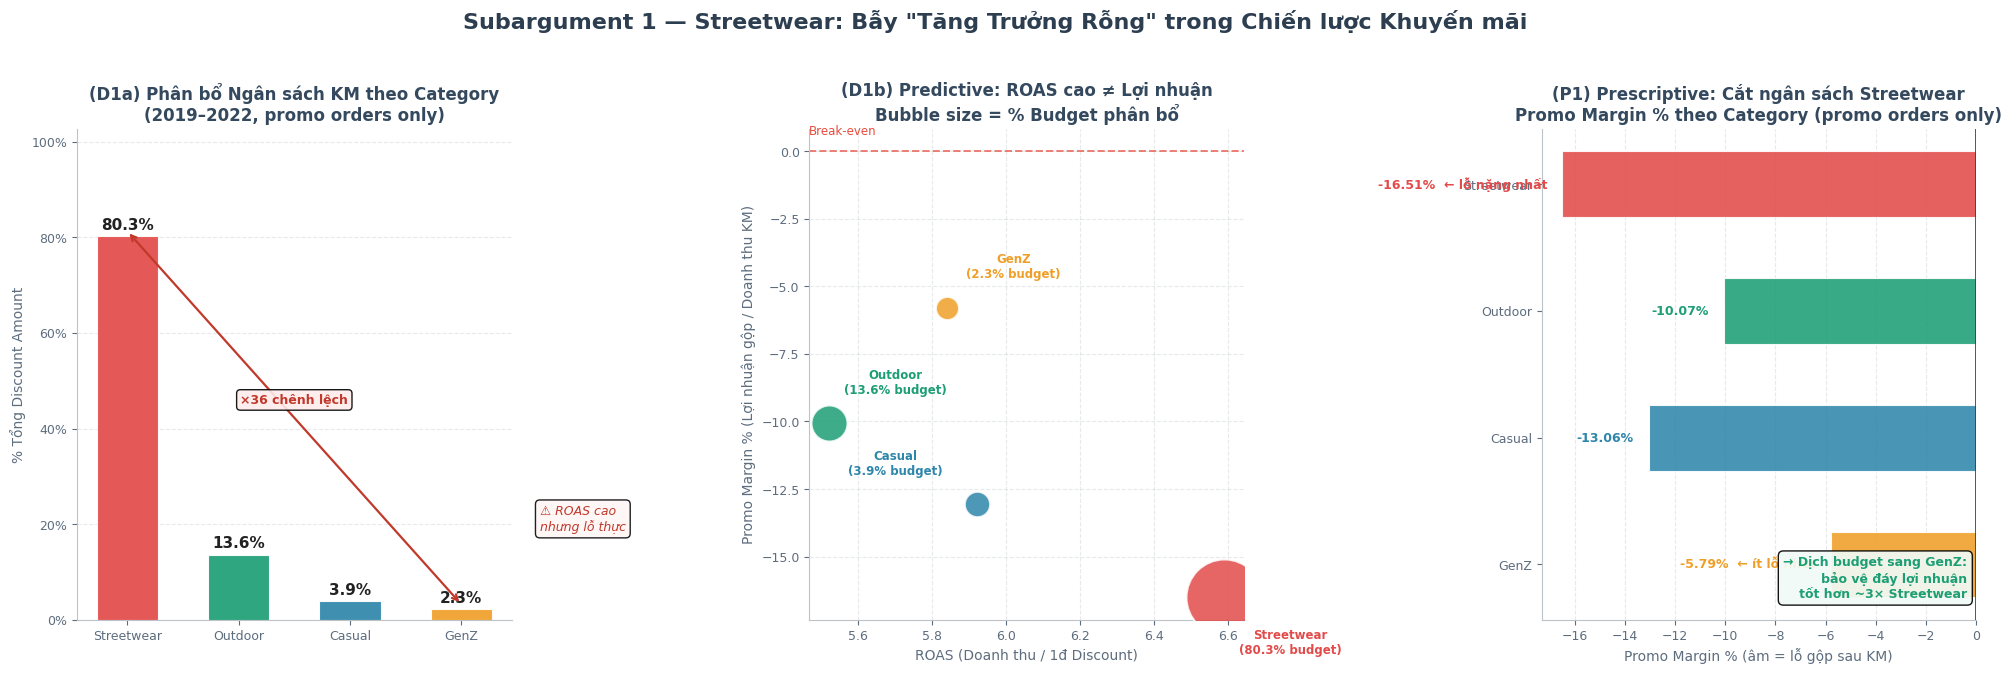

✅ Saved: fig1_subarg1_revised.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# SUBARGUMENT 1 — REVISED: "Bẫy Tăng Trưởng Rỗng" của Streetwear
# Pipeline: D1a (Budget share) | D1b (ROAS vs Promo Margin scatter) | P1 (Prescriptive)
# ════════════════════════════════════════════════════════════════════════════

# ── Load & transform data ────────────────────────────────────────────────────
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')

orders['year'] = orders['order_date'].dt.year

df = (order_items
      .merge(orders[['order_id', 'order_date', 'year']], on='order_id', how='left')
      .merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left'))

df['discount_amount'] = df['discount_amount'].fillna(0).abs()
df['gross_revenue']   = df['unit_price'] * df['quantity']
df['net_revenue']     = df['gross_revenue'] - df['discount_amount']
df['total_cogs']      = df['cogs'] * df['quantity']
df['gross_profit']    = df['net_revenue'] - df['total_cogs']

# Chỉ lấy đơn CÓ khuyến mãi, 2019–2022
promo_df = df[(df['year'].between(2019, 2022)) & (df['discount_amount'] > 0)].copy()

# ── Aggregate metrics (promo-only) ───────────────────────────────────────────
metrics = (promo_df.groupby('category')
           .agg(total_discount=('discount_amount', 'sum'),
                total_net_rev =('net_revenue',     'sum'),
                total_profit  =('gross_profit',    'sum'))
           .reset_index())

metrics['budget_share']   = metrics['total_discount'] / metrics['total_discount'].sum() * 100
metrics['ROAS']           = metrics['total_net_rev']  / metrics['total_discount']
metrics['promo_margin_%'] = metrics['total_profit']   / metrics['total_net_rev'] * 100
metrics = metrics.set_index('category').reindex(CAT_ORDER).reset_index()

bar_colors = [C_COLORS[c] for c in CAT_ORDER]

# ════════════════════════════════════════════════════════════════════════════
# FIGURE — 3 panels
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), facecolor='white')
fig.suptitle(
    'Subargument 1 — Streetwear: Bẫy "Tăng Trưởng Rỗng" trong Chiến lược Khuyến mãi',
    **FONT_SUP, y=1.03
)

# ── D1a: Budget Share ────────────────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(CAT_ORDER, metrics['budget_share'], color=bar_colors,
               width=0.55, alpha=0.92, zorder=3, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, metrics['budget_share']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='#222')

# Annotation: mũi tên chênh lệch SW vs GenZ
sw_val = metrics.loc[metrics['category'] == 'Streetwear', 'budget_share'].values[0]
gz_val = metrics.loc[metrics['category'] == 'GenZ',       'budget_share'].values[0]
mid_y  = (sw_val + gz_val) / 2 + 4
ax1.annotate('', xy=(3, gz_val + 1), xytext=(0, sw_val + 1),
             arrowprops=dict(arrowstyle='<->', color='#c0392b', lw=1.6))
ax1.text(1.5, mid_y, f'×{sw_val/gz_val:.0f} chênh lệch',
         ha='center', fontsize=9, color='#c0392b', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='#fdecea', alpha=0.9))

ax1.set_title('(D1a) Phân bổ Ngân sách KM theo Category\n(2019–2022, promo orders only)', **FONT_TITLE)
ax1.set_ylabel('% Tổng Discount Amount', **FONT_LABEL)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax1.set_ylim(0, sw_val * 1.28)
style_ax(ax1)

# ── D1b: ROAS vs Promo Margin — Scatter (bubble) ─────────────────────────────
ax2 = axes[1]

roas_vals   = metrics['ROAS'].values
margin_vals = metrics['promo_margin_%'].values
sizes       = (metrics['budget_share'].values / metrics['budget_share'].max()) * 2800 + 200

for i, cat in enumerate(CAT_ORDER):
    ax2.scatter(roas_vals[i], margin_vals[i],
                s=sizes[i], color=C_COLORS[cat],
                alpha=0.85, zorder=4, edgecolors='white', linewidth=1.5,
                label=cat)
    # Label: tên category + budget share
    offset_x = 0.18 if cat != 'Casual' else -0.22
    offset_y = 1.0  if cat != 'Streetwear' else -2.2
    ax2.text(roas_vals[i] + offset_x, margin_vals[i] + offset_y,
             f'{cat}\n({metrics.iloc[i]["budget_share"]:.1f}% budget)',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold',
             color=C_COLORS[cat])

# Đường margin = 0
ax2.axhline(y=0, color='#e74c3c', linestyle='--', linewidth=1.4, alpha=0.7, zorder=2)
ax2.text(ax2.get_xlim()[0] if ax2.get_xlim()[0] > 0 else roas_vals.min() - 0.3,
         0.5, 'Break-even', fontsize=8.5, color='#e74c3c', va='bottom')

# Quadrant annotation: góc nguy hiểm
ax2.text(roas_vals.max() * 0.72, margin_vals.min() * 0.85,
         '⚠ ROAS cao\nnhưng lỗ thực',
         fontsize=9, color='#c0392b', fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.35', fc='#fff5f5', alpha=0.88))

ax2.set_title('(D1b) Predictive: ROAS cao ≠ Lợi nhuận\nBubble size = % Budget phân bổ', **FONT_TITLE)
ax2.set_xlabel('ROAS (Doanh thu / 1đ Discount)', **FONT_LABEL)
ax2.set_ylabel('Promo Margin % (Lợi nhuận gộp / Doanh thu KM)', **FONT_LABEL)
style_ax(ax2, grid_axis='both')

# ── P1: Promo Margin % — Horizontal bar (Prescriptive) ──────────────────────
ax3 = axes[2]

m_vals  = metrics['promo_margin_%'].values
cat_rev = CAT_ORDER[::-1]   # đảo để GenZ ở trên cùng
m_rev   = m_vals[::-1]
c_rev   = bar_colors[::-1]

# Màu: xanh nếu ít âm nhất (GenZ), đỏ nếu âm sâu (Streetwear)
# Dùng alpha gradient để nhấn mạnh
bar_alpha = [0.95 if cat == 'GenZ' else 0.75 for cat in cat_rev]

hbars = ax3.barh(cat_rev, m_rev, color=c_rev, alpha=0.88,
                 height=0.52, edgecolor='white', linewidth=0.8, zorder=3)

ax3.axvline(x=0, color='#2C3E50', linewidth=1.2, zorder=4)

for bar, val, cat in zip(hbars, m_rev, cat_rev):
    x_pos = val - 0.6 if val < 0 else val + 0.2
    ha    = 'right' if val < 0 else 'left'
    label = f'{val:.2f}%'
    if cat == 'Streetwear':
        label += '  ← lỗ nặng nhất'
    elif cat == 'GenZ':
        label += '  ← ít lỗ nhất'
    ax3.text(x_pos, bar.get_y() + bar.get_height()/2,
             label, va='center', ha=ha,
             fontsize=9, fontweight='bold',
             color=C_COLORS[cat])

# Annotation prescriptive
ax3.text(0.98, 0.04,
         '→ Dịch budget sang GenZ:\n   bảo vệ đáy lợi nhuận\n   tốt hơn ~3× Streetwear',
         transform=ax3.transAxes, ha='right', va='bottom',
         fontsize=9, color='#1D9E75', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', fc='#f0faf6', alpha=0.92))

ax3.set_title('(P1) Prescriptive: Cắt ngân sách Streetwear\nPromo Margin % theo Category (promo orders only)', **FONT_TITLE)
ax3.set_xlabel('Promo Margin % (âm = lỗ gộp sau KM)', **FONT_LABEL)
style_ax(ax3, grid_axis='x')
ax3.grid(axis='y', visible=False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig1_subarg1_revised.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig1_subarg1_revised.png')

P2 margins →
  Streetwear: Peak=-9.32%, Off-peak=-18.72%  Δ=+9.41pp
  Outdoor: Peak=-21.66%, Off-peak=-6.63%  Δ=-15.03pp


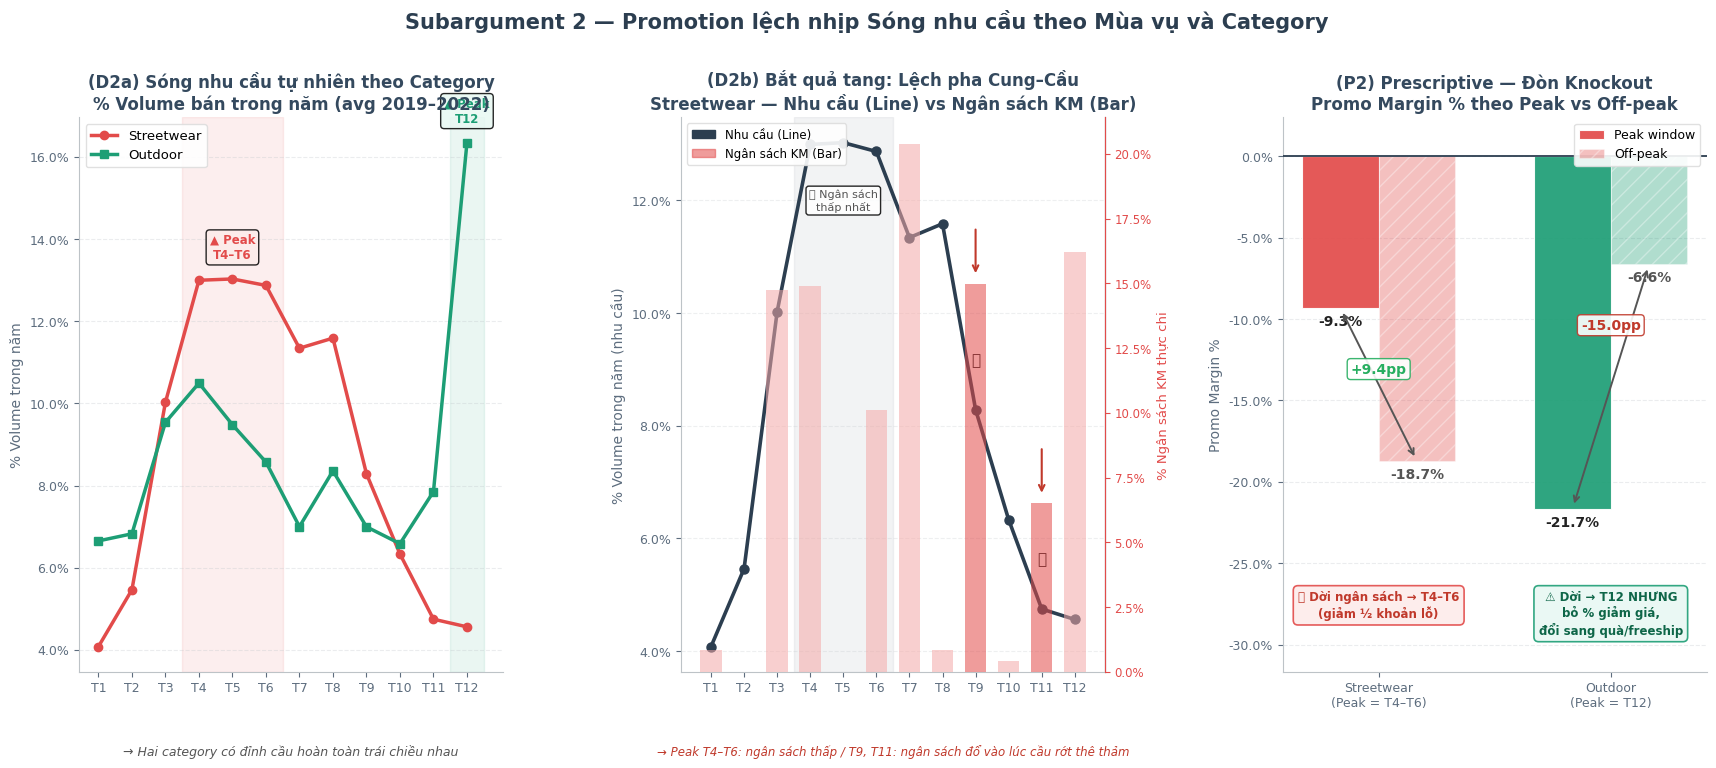

✅ Saved: fig2_subarg2_final.png


In [ ]:
# ── Load & transform ──────────────────────────────────────────────────────────
orders      = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products    = pd.read_csv(INPUT_DIR / 'products.csv')

orders['year']  = orders['order_date'].dt.year
orders['month'] = orders['order_date'].dt.month

df = (order_items
      .merge(orders[['order_id', 'year', 'month']], on='order_id', how='left')
      .merge(products[['product_id', 'category', 'cogs']], on='product_id', how='left'))

df['discount_amount'] = df['discount_amount'].fillna(0).abs()
df['gross_revenue']   = df['unit_price'] * df['quantity']
df['net_revenue']     = df['gross_revenue'] - df['discount_amount']
df['total_cogs']      = df['cogs'] * df['quantity']
df['gross_profit']    = df['net_revenue'] - df['total_cogs']

df_1922  = df[df['year'].between(2019, 2022)].copy()
promo_df = df_1922[df_1922['discount_amount'] > 0].copy()

# peak label
def assign_peak(row):
    if row['category'] == 'Streetwear' and row['month'] in [4, 5, 6]:
        return 'Peak'
    if row['category'] == 'Outdoor' and row['month'] == 12:
        return 'Peak'
    return 'Off-peak'

promo_df['peak_label'] = promo_df.apply(assign_peak, axis=1)

# ── D2a data: Volume share by month ───────────────────────────────────────────
sw_od = df[df['category'].isin(['Streetwear', 'Outdoor'])].copy()

vol_yr = (sw_od.groupby(['category', 'year', 'month'])['quantity']
          .sum().reset_index(name='qty'))
yr_total = (vol_yr.groupby(['category', 'year'])['qty']
            .sum().reset_index(name='yr_qty'))
vol_yr = vol_yr.merge(yr_total, on=['category', 'year'])
vol_yr['month_share'] = vol_yr['qty'] / vol_yr['yr_qty'] * 100

avg_vol = (vol_yr.groupby(['category', 'month'])['month_share']
           .mean().reset_index())

sw_vol = avg_vol[avg_vol['category'] == 'Streetwear'].set_index('month')['month_share'].reindex(range(1,13), fill_value=0)
od_vol = avg_vol[avg_vol['category'] == 'Outdoor'].set_index('month')['month_share'].reindex(range(1,13), fill_value=0)

# ── D2b data: Streetwear — Volume share vs Promo budget share by month ────────
sw_items = df_1922[df_1922['category'] == 'Streetwear'].copy()

# Volume share (natural demand) — reuse sw_vol
# Promo budget share by month for Streetwear
sw_promo = sw_items[sw_items['discount_amount'] > 0].copy()
promo_by_month = sw_promo.groupby('month')['discount_amount'].sum().reindex(range(1,13), fill_value=0)
promo_share = promo_by_month / promo_by_month.sum() * 100  # % of annual promo budget

# ── P2 data ───────────────────────────────────────────────────────────────────
p2_cats = promo_df[promo_df['category'].isin(['Streetwear', 'Outdoor'])].copy()

p2_agg = (p2_cats.groupby(['category', 'peak_label'])
          .agg(total_profit=('gross_profit', 'sum'),
               total_net_rev=('net_revenue', 'sum'))
          .reset_index())
p2_agg['promo_margin'] = p2_agg['total_profit'] / p2_agg['total_net_rev'] * 100

# ════════════════════════════════════════════════════════════════════════════
# DRAW
# ════════════════════════════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(21, 7.2), facecolor='white')
fig2.suptitle(
    'Subargument 2 — Promotion lệch nhịp Sóng nhu cầu theo Mùa vụ và Category',
    **FONT_SUP, y=1.03
)
gs = gridspec.GridSpec(1, 3, figure=fig2, wspace=0.42)

x = np.arange(1, 13)

# ─────────────────────────────────────────────────────────────────────────────
# D2a — Multi-line: Volume share Streetwear vs Outdoor
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig2.add_subplot(gs[0])

# Shaded peak windows
ax1.axvspan(3.5, 6.5, color='#E24B4A', alpha=0.09, zorder=0)
ax1.axvspan(11.5, 12.5, color='#1D9E75', alpha=0.09, zorder=0)

ax1.plot(x, sw_vol.values, color='#E24B4A', linewidth=2.5,
         marker='o', markersize=6, zorder=4, label='Streetwear')
ax1.plot(x, od_vol.values, color='#1D9E75', linewidth=2.5,
         marker='s', markersize=6, zorder=4, label='Outdoor')

# Peak labels inside shaded area
sw_peak_y = sw_vol[[4, 5, 6]].max()
ax1.text(5, sw_peak_y + 0.5, '▲ Peak\nT4–T6',
         ha='center', fontsize=8.5, color='#E24B4A',
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='#fdecea', alpha=0.85))
ax1.text(12, od_vol[12] + 0.5, '▲ Peak\nT12',
         ha='center', fontsize=8.5, color='#1D9E75',
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='#e8f8f3', alpha=0.85))

ax1.set_title('(D2a) Sóng nhu cầu tự nhiên theo Category\n% Volume bán trong năm (avg 2019–2022)', **FONT_TITLE)
ax1.set_ylabel('% Volume trong năm', **FONT_LABEL)
ax1.set_xticks(x)
ax1.set_xticklabels(MONTHS, fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax1.legend(fontsize=9.5, loc='upper left',
           framealpha=0.9, edgecolor='#ddd')
style_ax(ax1)

# insight note bottom
ax1.text(0.5, -0.15,
         '→ Hai category có đỉnh cầu hoàn toàn trái chiều nhau',
         transform=ax1.transAxes, ha='center', fontsize=9,
         color='#555', style='italic')

# ─────────────────────────────────────────────────────────────────────────────
# D2b — Dual-axis Combo: Streetwear demand (line) vs promo budget (bar)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig2.add_subplot(gs[1])
ax2r = ax2.twinx()

# — Bars: Promo budget share (Y2, right axis) —
bar_colors_d2b = ['#E24B4A' if m in [9, 11] else '#f4a9a8' for m in range(1, 13)]
bars = ax2r.bar(x, promo_share.values, color=bar_colors_d2b,
                alpha=0.55, width=0.65, zorder=2, label='% Ngân sách KM')
ax2r.set_ylabel('% Ngân sách KM thực chi', fontsize=9.5, color='#E24B4A')
ax2r.tick_params(axis='y', colors='#E24B4A', labelsize=8.5)
ax2r.spines['top'].set_visible(False)
ax2r.spines['right'].set_color('#E24B4A')
ax2r.spines['left'].set_visible(False)
ax2r.spines['bottom'].set_visible(False)
ax2r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))

# — Line: Natural demand (Y1, left axis) —
ax2.plot(x, sw_vol.values, color='#2C3E50', linewidth=2.6,
         marker='o', markersize=6.5, zorder=5, label='% Volume nhu cầu')
ax2.set_ylabel('% Volume trong năm (nhu cầu)', **FONT_LABEL)
ax2.set_xticks(x)
ax2.set_xticklabels(MONTHS, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))

# Shade peak demand window (T4–T6) on D2b too
ax2.axvspan(3.5, 6.5, color='#2C3E50', alpha=0.06, zorder=0)

# Highlight "mismatch" months: demand low, budget high → T9, T11
for m, bad_m in enumerate([9, 11], start=1):
    b_y = promo_share[bad_m]
    d_y = sw_vol[bad_m]
    ax2r.annotate('',
        xy=(bad_m, b_y + 0.3),
        xytext=(bad_m, b_y + 2.2),
        arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

# Text boxes for mismatch
ax2.text(9, sw_vol[9] + 0.8, '❌', ha='center', fontsize=11, zorder=6)
ax2.text(11, sw_vol[11] + 0.8, '❌', ha='center', fontsize=11, zorder=6)
ax2.text(5, sw_vol[[4,5,6]].max() - 1.2, '📉 Ngân sách\nthấp nhất',
         ha='center', fontsize=8, color='#555', zorder=6,
         bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.85))

# Legend
h_line = mpatches.Patch(color='#2C3E50', label='Nhu cầu (Line)')
h_bar  = mpatches.Patch(color='#E24B4A', alpha=0.55, label='Ngân sách KM (Bar)')
ax2.legend(handles=[h_line, h_bar], fontsize=8.5, loc='upper left',
           framealpha=0.9, edgecolor='#ddd')

ax2.set_title('(D2b) Bắt quả tang: Lệch pha Cung–Cầu\nStreetwear — Nhu cầu (Line) vs Ngân sách KM (Bar)', **FONT_TITLE)
style_ax(ax2, keep_right_spine=True)
ax2.grid(axis='y', linestyle='--', alpha=0.25, color='#BDC3C7', zorder=0)

ax2.text(0.5, -0.15,
         '→ Peak T4–T6: ngân sách thấp / T9, T11: ngân sách đổ vào lúc cầu rớt thê thảm',
         transform=ax2.transAxes, ha='center', fontsize=8.5,
         color='#c0392b', style='italic')

# ─────────────────────────────────────────────────────────────────────────────
# P2 — Grouped Bar: Promo Margin % Peak vs Off-peak
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig2.add_subplot(gs[2])

cats_p2 = ['Streetwear', 'Outdoor']
x_p2    = np.arange(len(cats_p2))
width   = 0.33

peak_margins, offpeak_margins = [], []
for cat in cats_p2:
    sub = p2_agg[p2_agg['category'] == cat]
    pk  = sub[sub['peak_label'] == 'Peak']['promo_margin'].values
    op  = sub[sub['peak_label'] == 'Off-peak']['promo_margin'].values
    peak_margins.append(pk[0] if len(pk) else 0)
    offpeak_margins.append(op[0] if len(op) else 0)

print("P2 margins →")
for cat, pk, op in zip(cats_p2, peak_margins, offpeak_margins):
    print(f"  {cat}: Peak={pk:.2f}%, Off-peak={op:.2f}%  Δ={pk-op:+.2f}pp")

# Draw bars
bars_pk = ax3.bar(x_p2 - width/2, peak_margins, width,
                  color=[C_COLORS[c] for c in cats_p2],
                  alpha=0.92, label='Peak window', zorder=3,
                  edgecolor='white', linewidth=0.8)
bars_op = ax3.bar(x_p2 + width/2, offpeak_margins, width,
                  color=[C_COLORS[c] for c in cats_p2],
                  alpha=0.35, label='Off-peak', zorder=3,
                  edgecolor='white', linewidth=0.8, hatch='//')

# Value labels on bars
for bar, val, solid in zip(list(bars_pk) + list(bars_op),
                            peak_margins + offpeak_margins,
                            [True]*2 + [False]*2):
    fc  = '#222' if solid else '#555'
    va  = 'top' if val < 0 else 'bottom'
    off = -0.4 if val < 0 else 0.4
    ax3.text(bar.get_x() + bar.get_width()/2, val + off,
             f'{val:.1f}%', ha='center', va=va,
             fontsize=10, fontweight='bold', color=fc)

# Break-even
ax3.axhline(y=0, color='#2C3E50', linewidth=1.3, zorder=5)

# Delta annotation (double-headed arrow between bar tops/bottoms)
for i, (pk, op, cat) in enumerate(zip(peak_margins, offpeak_margins, cats_p2)):
    delta = pk - op
    sign  = '+' if delta >= 0 else ''
    # Arrow between the *tips* of the two bars
    y_pk = pk
    y_op = op
    y_hi = max(y_pk, y_op)
    y_lo = min(y_pk, y_op)
    # Draw bracket arrow
    ax3.annotate('',
        xy  =(i - width/2, y_pk),
        xytext=(i + width/2, y_op),
        arrowprops=dict(arrowstyle='<->', color='#555',
                        lw=1.4, shrinkA=4, shrinkB=4))
    # Delta label: place above the higher of the two
    label_y = y_hi + (2.5 if y_hi >= 0 else -4)
    ax3.text(i, label_y,
             f'{sign}{delta:.1f}pp',
             ha='center', fontsize=10, fontweight='bold',
             color='#27ae60' if delta > 0 else '#c0392b',
             bbox=dict(boxstyle='round,pad=0.25', fc='white',
                       ec='#27ae60' if delta > 0 else '#c0392b',
                       alpha=0.9))

# ── Insight annotation boxes ──────────────────────────────────────────────────
y_min = min(peak_margins + offpeak_margins)
box_y = y_min - 5  # position below lowest bar

# Streetwear insight
ax3.text(0, box_y,
         '✅ Dời ngân sách → T4–T6\n(giảm ½ khoản lỗ)',
         ha='center', va='top', fontsize=8.5,
         color='#c0392b', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', fc='#fdecea',
                   ec='#E24B4A', alpha=0.9, linewidth=1.2))

# Outdoor insight
ax3.text(1, box_y,
         '⚠️ Dời → T12 NHƯNG\nbỏ % giảm giá,\nđổi sang quà/freeship',
         ha='center', va='top', fontsize=8.5,
         color='#0e6648', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', fc='#e8f8f3',
                   ec='#1D9E75', alpha=0.9, linewidth=1.2))

# Adjust y-limit to show insight boxes
ax3.set_ylim(box_y - 5, max(peak_margins + offpeak_margins) + 9)

ax3.set_title('(P2) Prescriptive — Đòn Knockout\nPromo Margin % theo Peak vs Off-peak', **FONT_TITLE)
ax3.set_ylabel('Promo Margin %', **FONT_LABEL)
ax3.set_xticks(x_p2)
ax3.set_xticklabels(['Streetwear\n(Peak = T4–T6)', 'Outdoor\n(Peak = T12)'], fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax3.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor='#ddd')
style_ax(ax3)

plt.tight_layout(rect=[0, 0.02, 1, 1])
fig2.savefig(OUTPUT_DIR / 'fig2_subarg2_final.png', dpi=200,
             bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Saved: fig2_subarg2_final.png')